In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

crypto_list = ['ADA', 'BCH', 'BNB', 'BTC', 'ETC', 'ETH', 'LINK', 'LTC', 'XLM', 'XRP'] # We have created a list with crypto currencies. Our csv data files contain the name
df_list = {}                                                                          # We create an empty dictionary where to store all data
for crypto in crypto_list:                                                            # Create a loop that will go through the list of crypto currencies
    df_list[crypto] = pd.read_csv(f"{crypto}-USDT.csv")                               # This line will read specific csv files in the directory
    df_list[crypto]['date'] = pd.to_datetime(df_list[crypto]['date'], unit='ms')      # This line will set date time to human readable format
    df_list[crypto] = df_list[crypto].set_index('date')                              # This line will set date as an index
    duplicated_data = df_list[crypto].index.duplicated(keep='last')
    df_list[crypto].loc[duplicated_data]                                 
    df_list[crypto] = df_list[crypto][~duplicated_data]

In [2]:
df_list['BTC'].describe() # Overall look at the data, to see if we might be missing some information

,open,high,low,close,volume
count,51383.000000,51383.000000,51383.000000,51383.000000,51383.000000
mean,19953.441256,20062.614602,19837.535492,19953.945733,3200.337733
std,16125.883658,16215.651611,16030.902587,16125.807732,4472.817863
min,2870.900000,2950.000000,2817.000000,2919.000000,0.000000
25%,7555.510000,7597.320000,7520.000000,7556.670000,1015.423808
50%,11535.770000,11600.000000,11469.270000,11539.700000,1770.308040
75%,29500.860000,29629.275000,29357.255000,29502.095000,3479.318780
max,68635.120000,69000.000000,68451.190000,68633.690000,137207.188600


In [3]:
df_list['ADA'].index.nunique(), len(df_list['ADA']) # If we compare unique indexes with all rows in the data set we see a difference

(45591, 45591)

In [4]:
# Here we address duplicate issue in the data frame (After below was established here it was added to main loop at the top of the page)

#duplicated_data = df_list['BTC'].index.duplicated(keep='last')
#df_list['BTC'].loc[duplicated_data]                                 
#df_list['BTC'] = df_list['BTC'][~duplicated_data]


In [5]:
df =pd.DataFrame()           # Creating an empty dataframe
for crypto in df_list:
    print(crypto)
    df[crypto] = df_list[crypto]['close']

ADA
BCH
BNB
BTC
ETC
ETH
LINK
LTC
XLM
XRP


In [6]:
#df['ADA']                   # Now when we call this we only get close price for ADA
#df                          # Now when we call this we get close price fore cryptos in our list
df = df.dropna()                 # Running this method removes NaNs in the dataframe. In the meantime we also loose data that were in the same rows as NaNs

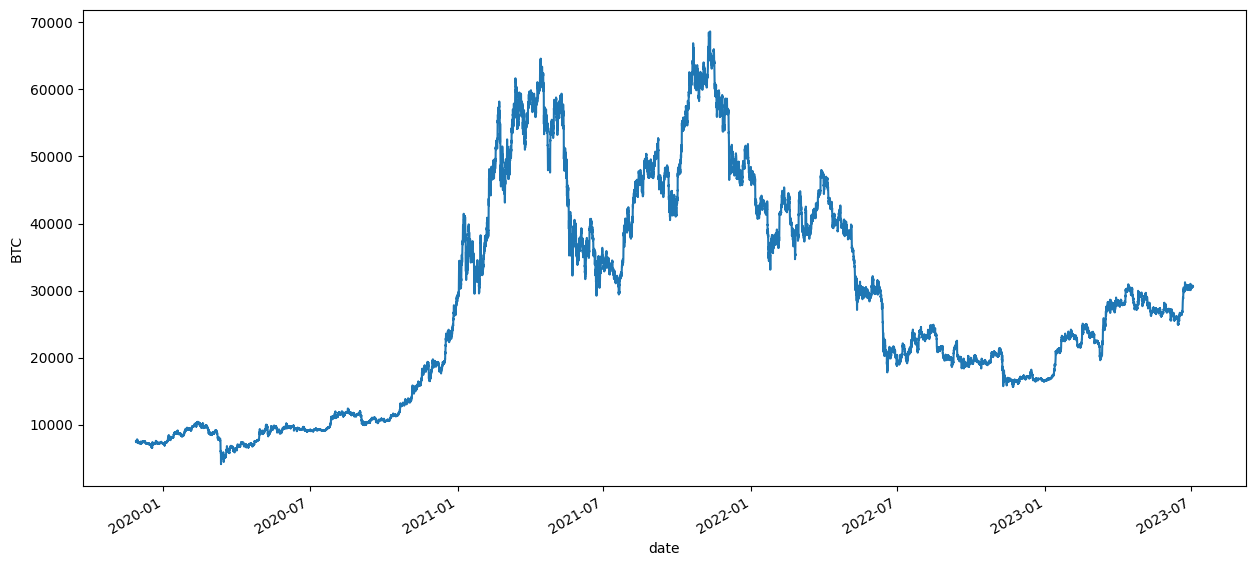

In [7]:
# Here is a solution to show plot for one of the crypto currencies
fig, ax = plt.subplots(figsize=(15, 7))
df['BTC'].plot(label='BTC')
ax.set_ylabel('BTC') # Displays the name of the cryptocurrency on the Y-axis
plt.show()

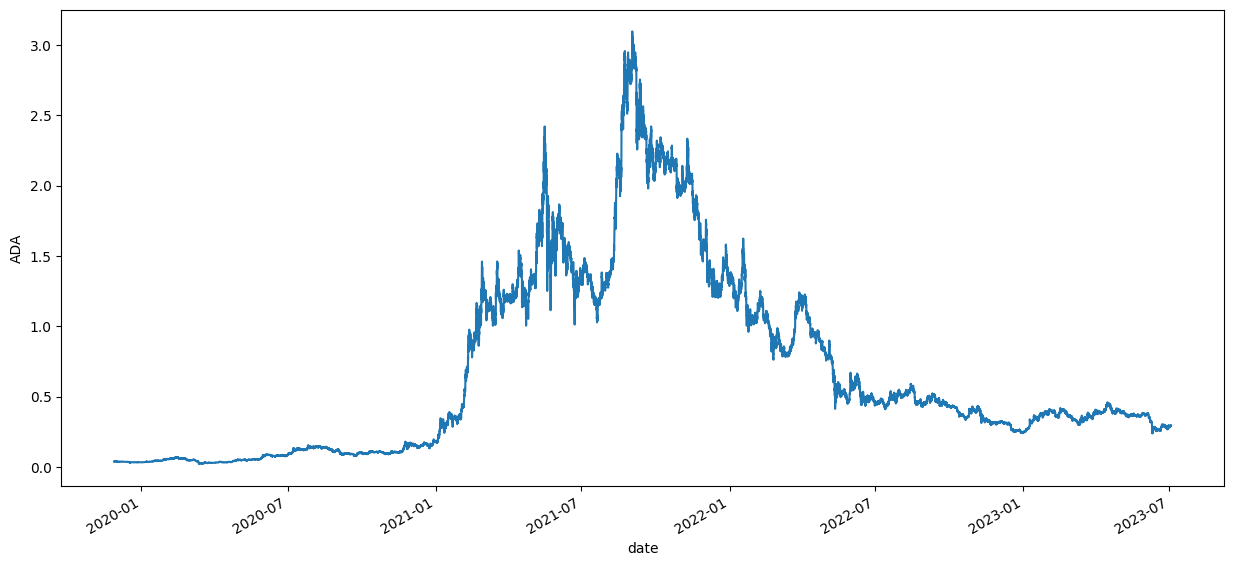

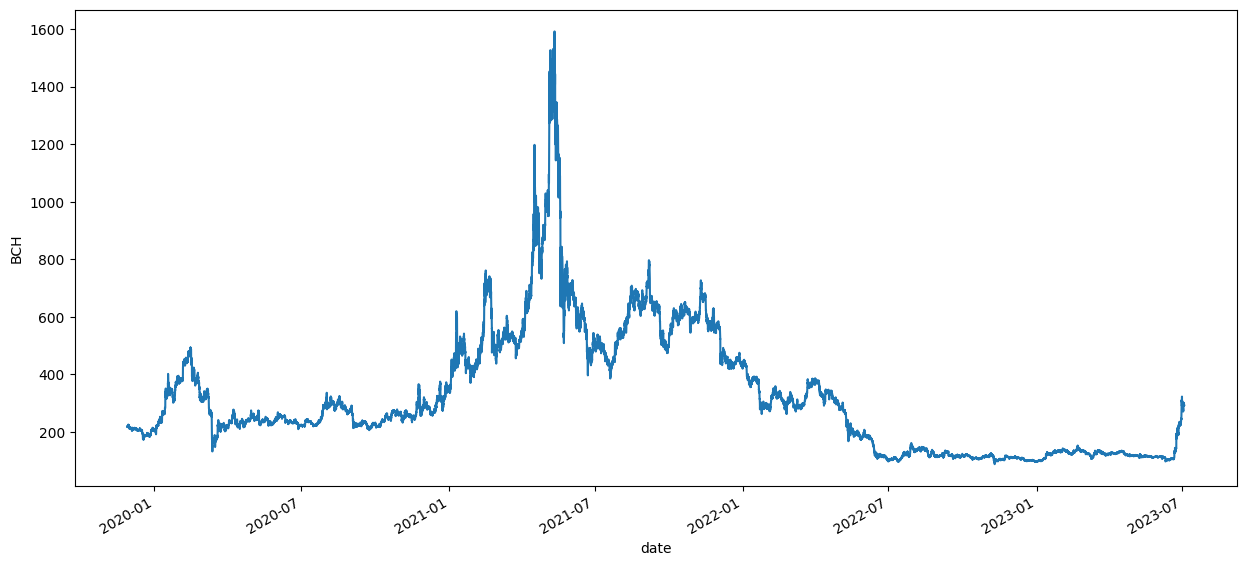

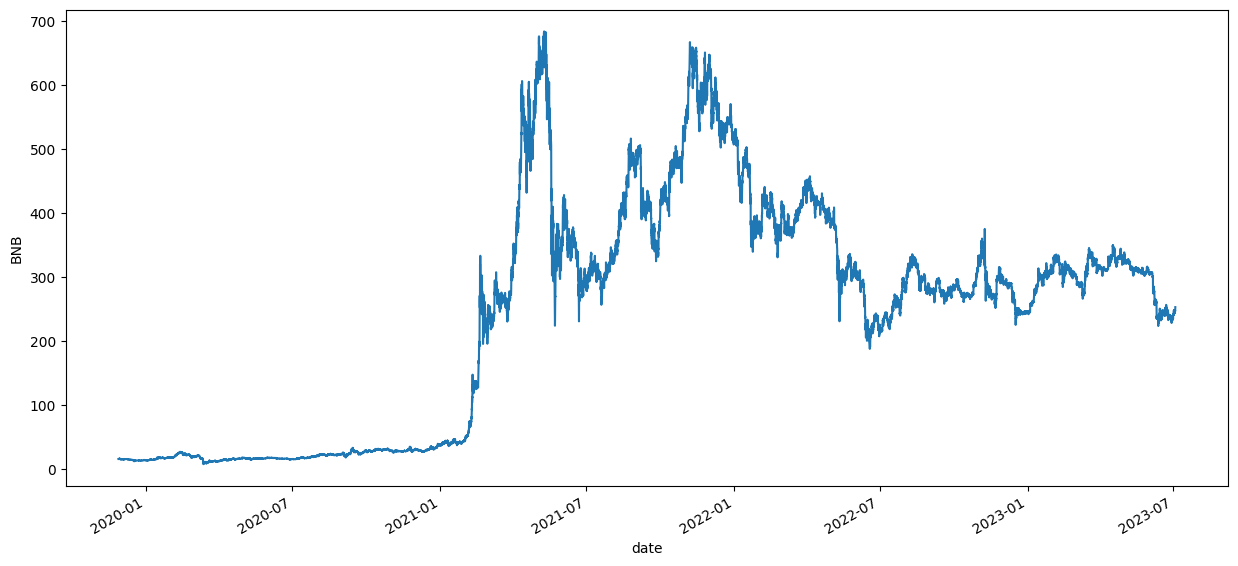

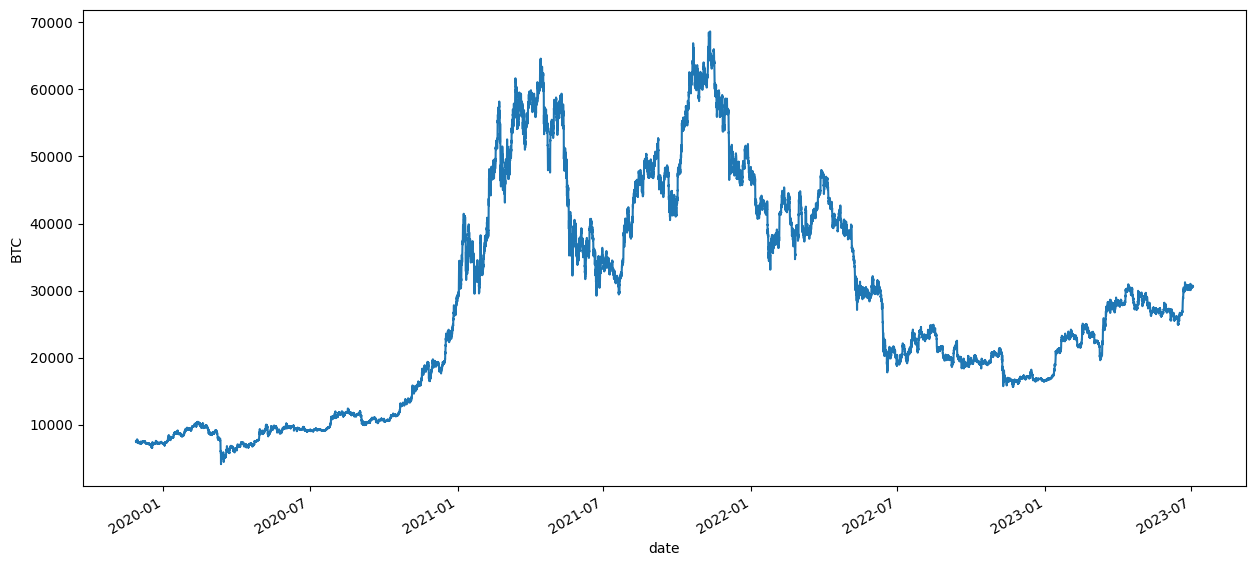

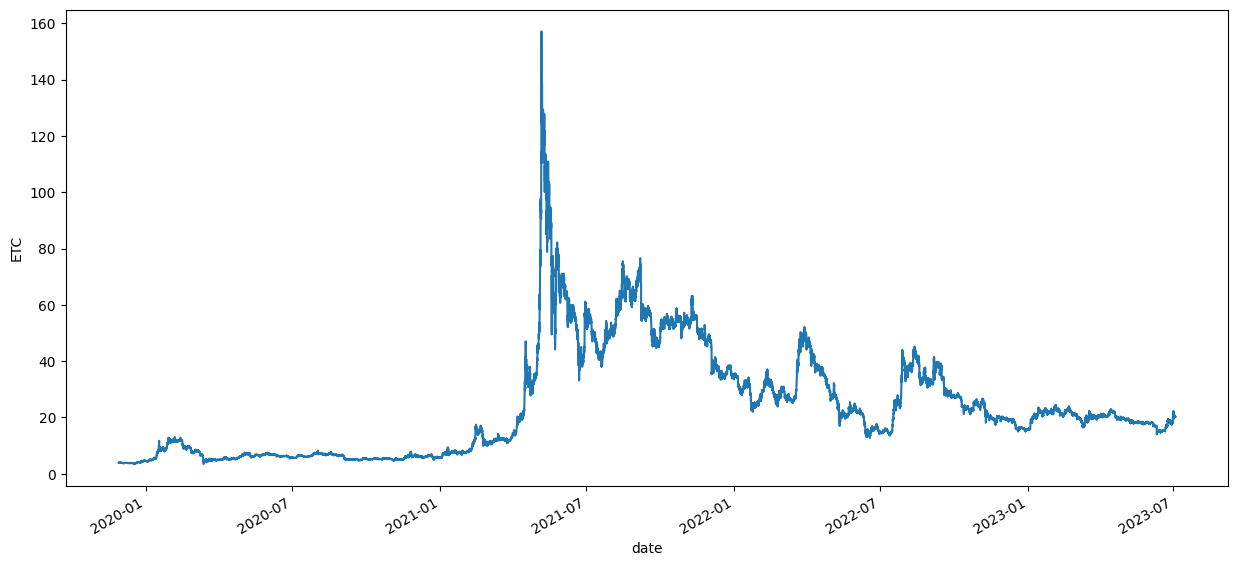

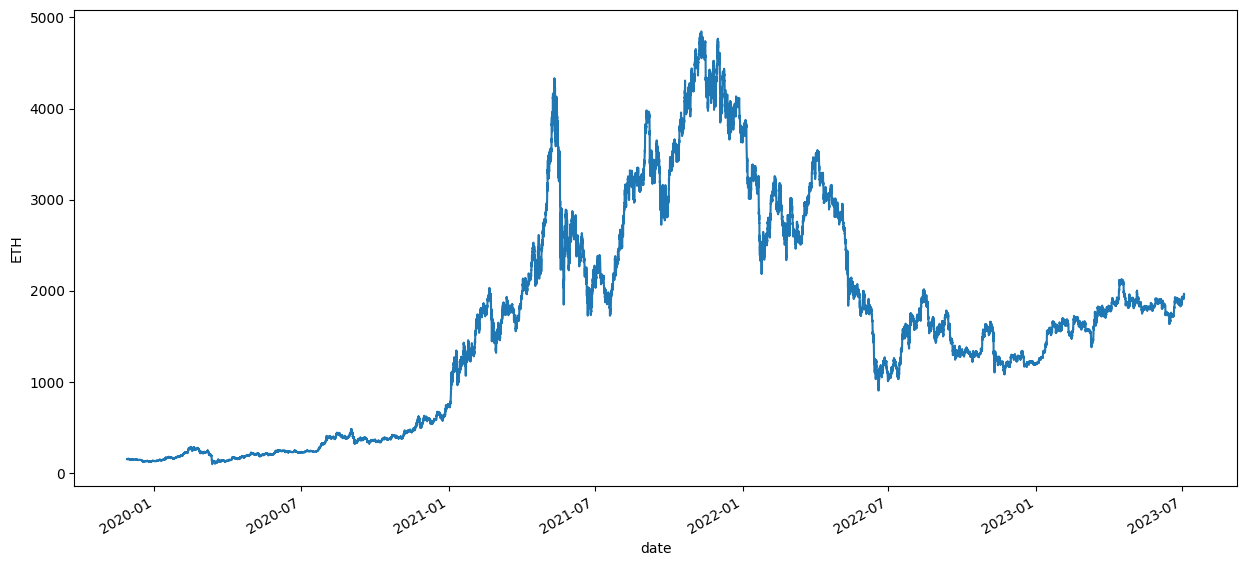

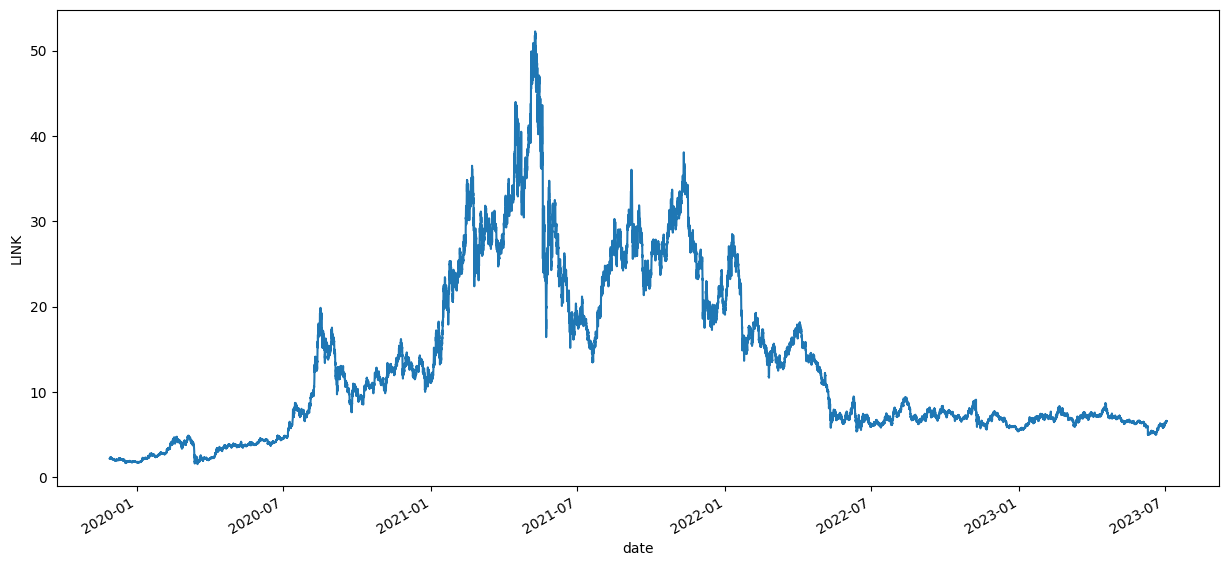

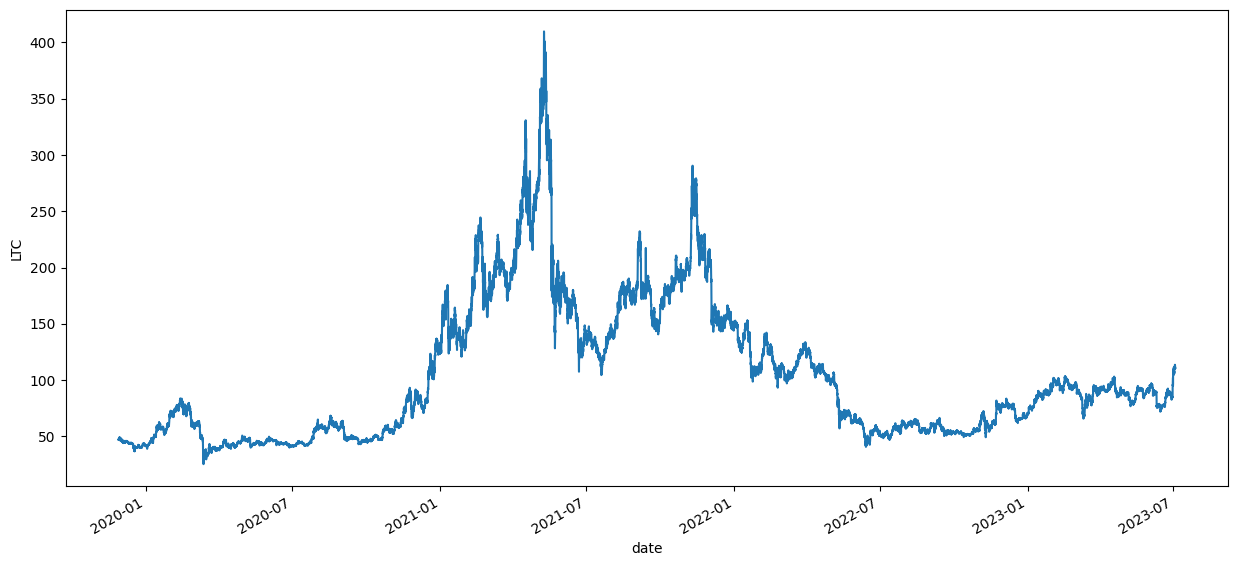

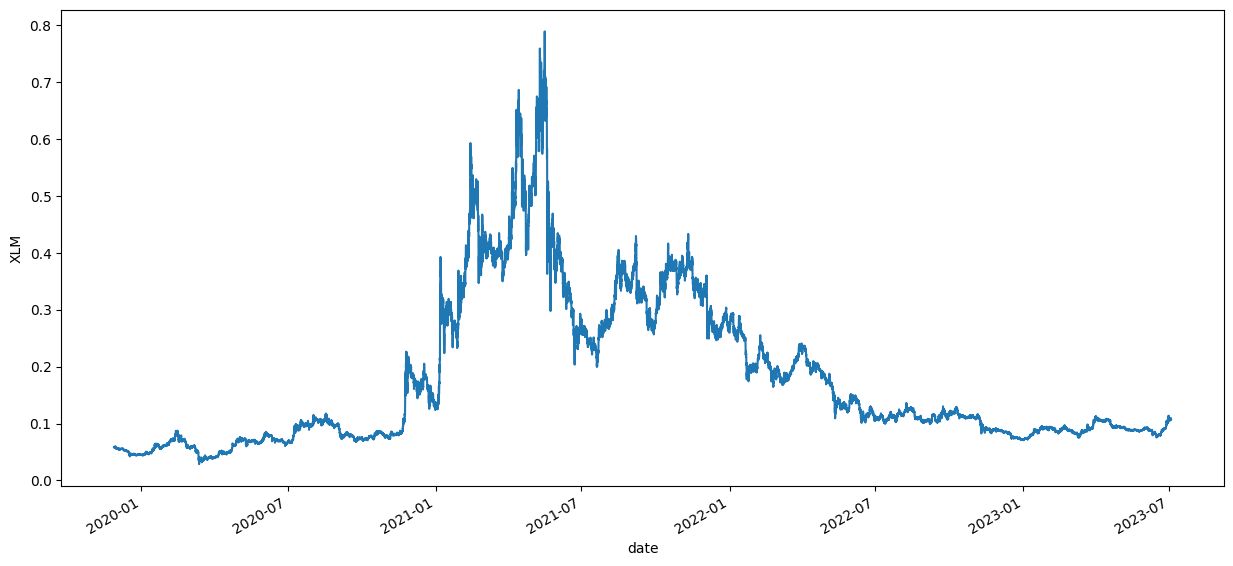

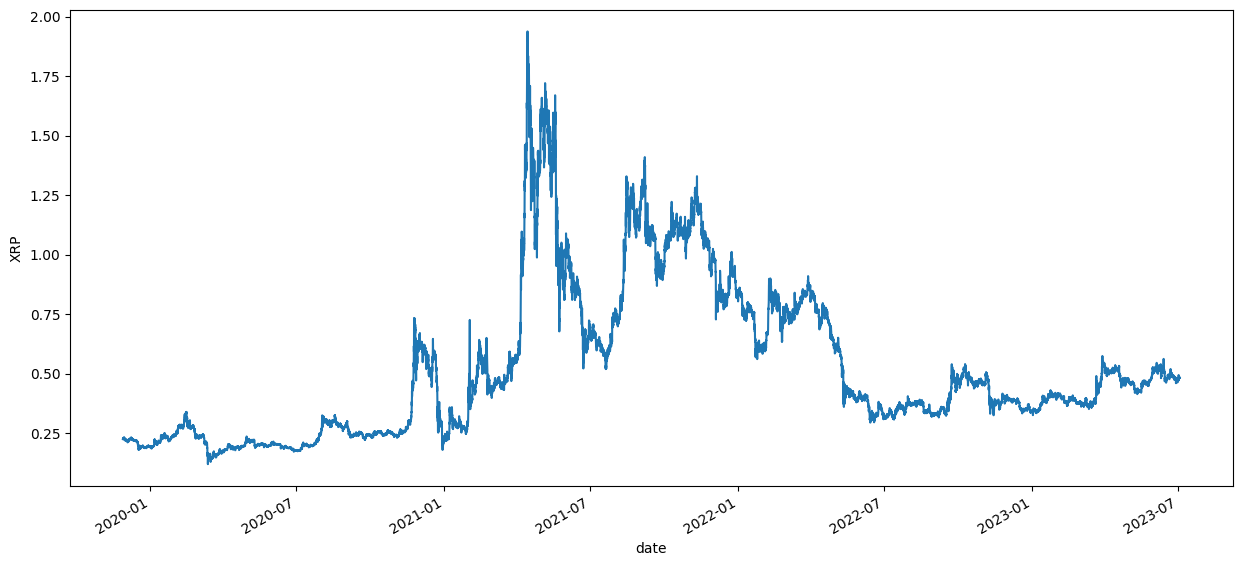

In [8]:
# With loop we can create plots for all currencies
for col in df.columns:
    fig, ax = plt.subplots(figsize=(15, 7))
    df[col].plot(label=col)
    ax.set_ylabel(col) # Displays the name of the cryptocurrency on the Y-axis
    plt.show()

In [9]:
# Correlation matrix measures the degree of association between two variables. Can be positive or negative
df.corr()

,ADA,BCH,BNB,BTC,ETC,ETH,LINK,LTC,XLM,XRP
ADA,1.000000,0.723569,0.782634,0.859911,0.848417,0.869297,0.819000,0.805404,0.803867,0.887277
BCH,0.723569,1.000000,0.430161,0.690909,0.638144,0.532628,0.890495,0.889421,0.896184,0.767310
BNB,0.782634,0.430161,1.000000,0.822675,0.800248,0.939650,0.610371,0.688569,0.619362,0.834212
BTC,0.859911,0.690909,0.822675,1.000000,0.680973,0.896195,0.860330,0.897080,0.870901,0.853319
ETC,0.848417,0.638144,0.800248,0.680973,1.000000,0.820675,0.659701,0.689580,0.662189,0.833492
ETH,0.869297,0.532628,0.939650,0.896195,0.820675,1.000000,0.700819,0.746219,0.686731,0.861432
LINK,0.819000,0.890495,0.610371,0.860330,0.659701,0.700819,1.000000,0.940221,0.960905,0.836123
LTC,0.805404,0.889421,0.688569,0.897080,0.689580,0.746219,0.940221,1.000000,0.953542,0.861605
XLM,0.803867,0.896184,0.619362,0.870901,0.662189,0.686731,0.960905,0.953542,1.000000,0.833596
XRP,0.887277,0.767310,0.834212,0.853319,0.833492,0.861432,0.836123,0.861605,0.833596,1.000000


<Axes: >

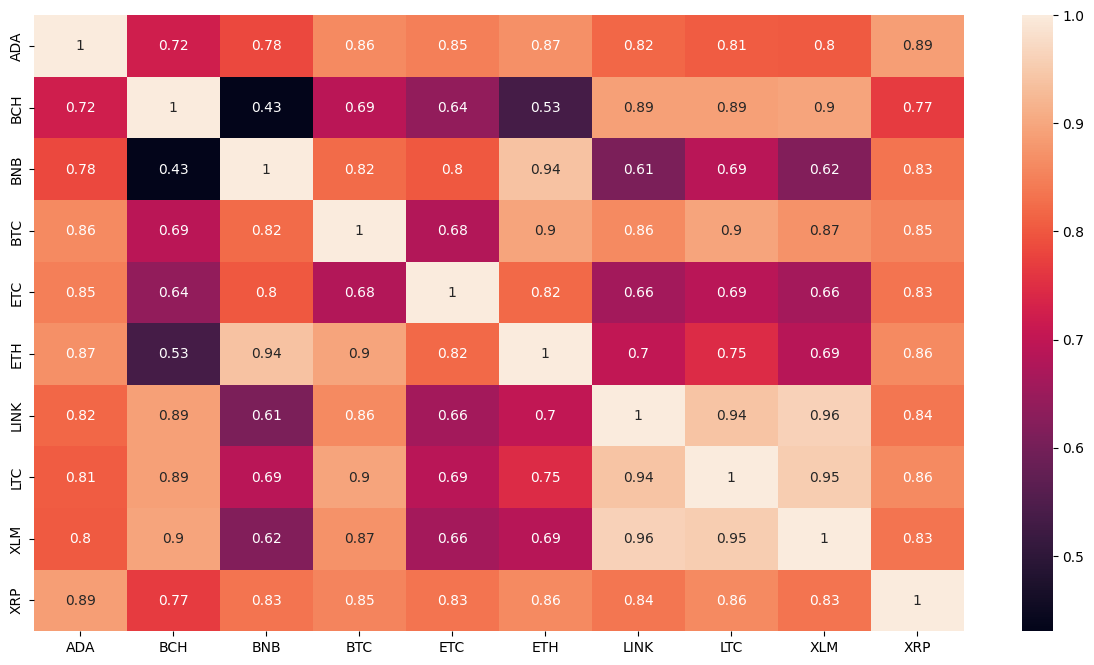

In [10]:
# The above is quite hard to visualize. We will import seaborn to see a different plot

f, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(df.loc[:].corr(), annot=True)

In [11]:
df_pct = df.pct_change() # Computes percentage change in between values. First row is NaN as it does not have previous data
df_pct

,ADA,BCH,BNB,BTC,ETC,ETH,LINK,LTC,XLM,XRP
date,,,,,,,,,,
2019-11-28 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-11-28 11:00:00,0.006216,0.000274,0.000523,0.000128,0.003076,0.002911,0.007111,0.002752,0.000172,0.003151
2019-11-28 12:00:00,-0.009009,-0.006894,-0.014893,-0.004736,-0.007933,-0.005146,-0.015321,-0.010980,-0.002578,-0.004602
2019-11-28 13:00:00,-0.001039,0.003494,0.000141,0.001552,0.004675,0.001525,-0.003247,0.001494,-0.002413,-0.000667
2019-11-28 14:00:00,0.007540,0.001741,0.004150,0.000515,0.001551,-0.000861,0.010588,0.002558,0.002418,0.001423
...,...,...,...,...,...,...,...,...,...,...
2023-07-03 06:00:00,-0.003070,-0.015483,0.002027,-0.000729,-0.004440,0.001172,-0.004701,-0.004715,0.001847,0.000207
2023-07-03 07:00:00,0.006500,0.009573,0.009304,0.000520,0.007929,0.009744,0.010666,0.004112,0.007373,-0.003524
2023-07-03 08:00:00,0.002039,-0.005418,-0.003607,-0.000883,-0.009341,-0.003462,-0.002261,-0.014955,-0.018298,0.006449


<Axes: >

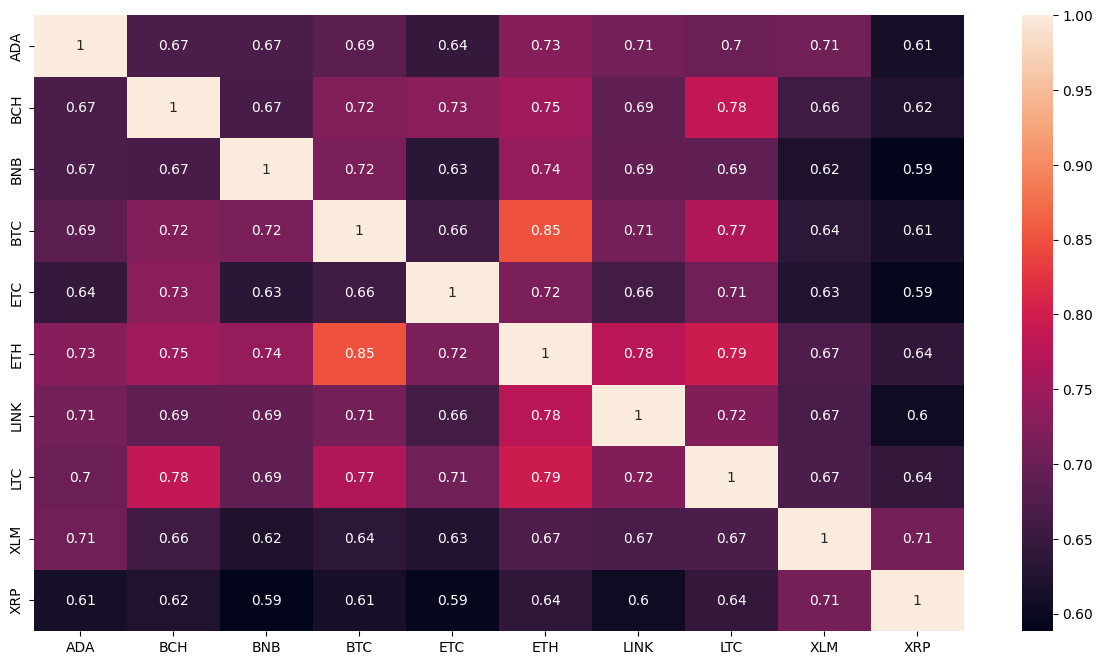

In [12]:
f, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(df_pct.corr(), annot=True)

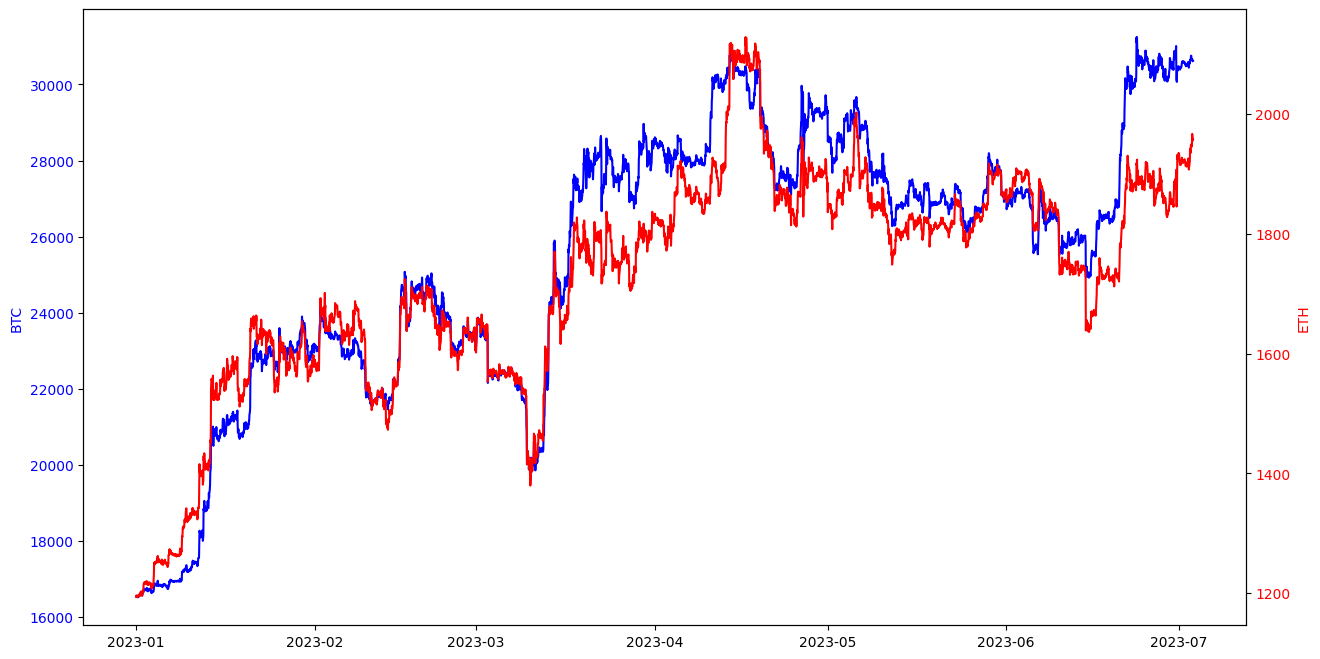

In [13]:
# Comparing two assets by plotting their prices on two different y-axis, but sharing x-asis
fig, ax = plt.subplots(figsize=(15, 8))         # Initializing plot

data = df.loc["2023"]                           # Specifically looking at year 2023
#data =df.loc[:]                               # With you would look at full range
#data =df.loc['2023':]                          # With this would look at range from 2023 till
asset1 = "BTC"
asset2 = "ETH"
# Plot the first asset on the primary axis
ax.plot(data.index, data[asset1], color='blue')
ax.set_ylabel(asset1, color='blue')
ax.tick_params(axis='y', labelcolor='blue')

# Create a second axis sharing the same x-axis
ax2 = ax.twinx()

# Plot the second asset on the secondary axis
ax2.plot(data.index, data[asset2], color='red')
ax2.set_ylabel(asset2, color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.show()

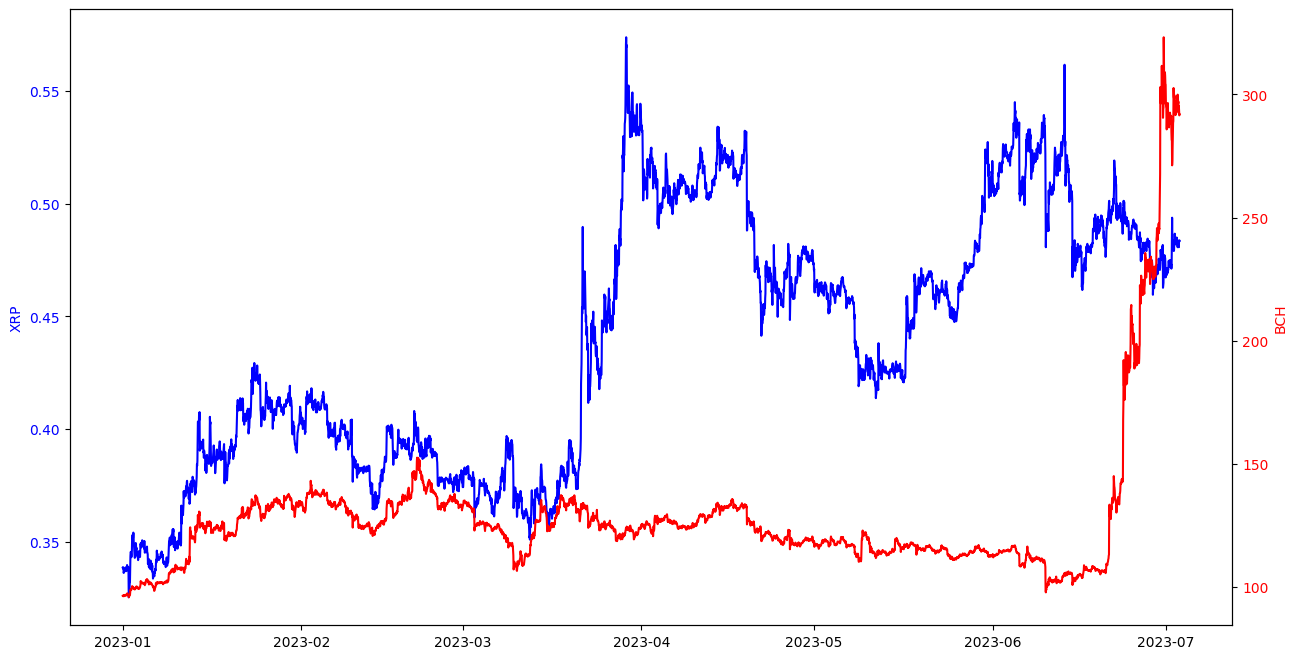

In [14]:
# Comparing two assets that have the least correlation
fig, ax = plt.subplots(figsize=(15, 8))         

data = df.loc["2023"]                                               
asset1 = "XRP"
asset2 = "BCH"
# Plot the first asset on the primary axis
ax.plot(data.index, data[asset1], color='blue')
ax.set_ylabel(asset1, color='blue')
ax.tick_params(axis='y', labelcolor='blue')

# Create a second axis sharing the same x-axis
ax2 = ax.twinx()

# Plot the second asset on the secondary axis
ax2.plot(data.index, data[asset2], color='red')
ax2.set_ylabel(asset2, color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.show()

<Axes: >

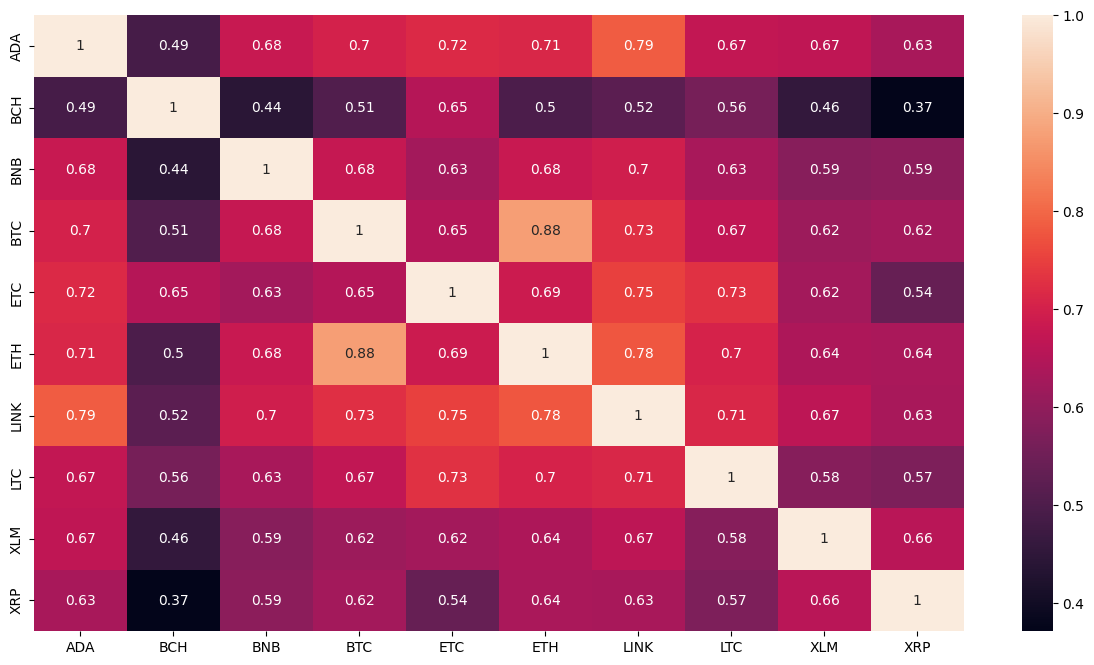

In [15]:
f, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(df_pct.loc['2023-04':].corr(), annot=True)

In [16]:
# Video till 41:48 min